# Proof of concept of the PINN: 1D Damped harmonic oscillator

We will be looking at the equation:

$$m\frac{d^2u}{dt^2}+c\frac{du}{dt} + ku = 0$$

With (abritrary units): 
* $m=1.0$,
* $c=1.0$,
* $k=2.0$, 
* $u(t=0)=1$,
* $\frac{dt}{dt}(t=0) = 0$



In [1]:
from __future__ import annotations

import os
import sys

# import time
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import random
import equinox as eqx
import jax
import jax.numpy as jnp
from jax.random import PRNGKey
import jax.random as jr
import optax

import matplotlib.pyplot as plt
from matplotlib import rcParams

## Part 1: Consider $k, m, c$ known parameters. We also have loads of data for the data loss

In [2]:
K = 2.0
M = 1.0
C = 1.0
t_max = 10.0
LEARNING_RATE = 1e-2


In [3]:
# Reference function
from scipy.integrate import solve_ivp


def reference_function(t_eval, m=M, c=C, k=K, u0=1.0, v0=0.0):
    """Compute the numerical solution using Scipy's Runge-Kutta solver"""

    # Define the system of 1st-order ODEs
    def dY_dt(t, Y):
        u, v = Y
        du_dt = v
        dv_dt = -(c * v + k * u) / m
        return [du_dt, dv_dt]

    # Time span needs to cover the evaluation points
    t_span = (float(t_eval[0]), float(t_eval[-1]))
    Y0 = [u0, v0]

    # solve_ivp returns an object; sol.y[0] contains the displacements
    sol = solve_ivp(dY_dt, t_span, Y0, t_eval=t_eval, method="RK45")

    return sol.y[0]

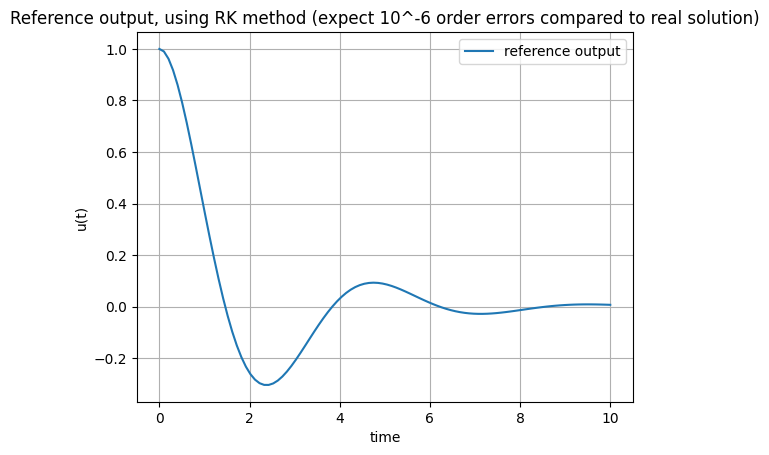

In [4]:
t_inter = jnp.linspace(0, int(t_max), 100)
interval_size = len(t_inter)
u_ref = reference_function(t_inter)

plt.plot(t_inter, u_ref, label="reference output")
plt.title(
    "Reference output, using RK method (expect 10^-6 order errors compared to real solution)"
)
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()

## Onto the PINN

We start with a simple architecture. 

In [5]:
key = jr.PRNGKey(42)
key, init_key = jr.split(key)


class NormalizedPINN(eqx.Module):
    mlp: eqx.nn.MLP

    # domain boundaries
    t_max: float = t_max

    def __init__(self, key):
        # Build the architecture and store it inside 'self.mlp'
        self.mlp = eqx.nn.MLP(
            # in_size=3,
            in_size=1,
            out_size=1,
            width_size=64,
            depth=4,
            activation=jax.nn.silu,
            key=key,
        )

    def __call__(self, coords):
        # Intercept the coordinates and normalize them then centers around 0 +/- 1
        t_norm = (coords / self.t_max) * 2.0 - 1.0
        scaled_coords = jnp.array([t_norm])

        # Pass the safe, normalized coordinates to the architecture
        return self.mlp(scaled_coords)


pinn = NormalizedPINN(init_key)

**Architecture choices:**

- **Input normalization**: $t \in [0, t_\text{max}]$ is mapped to $[-1, 1]$. This keeps the network inputs well-conditioned and avoids activation saturation near the boundary.
- **SiLU activation** (`x · sigmoid(x)`): smooth and nonzero second derivative everywhere. This matters because we differentiate through the network twice to compute $\ddot{u}$; a piecewise-linear activation (e.g. ReLU) would yield zero Hessians everywhere.
- **4 hidden layers × 64 units**: enough capacity to represent a damped oscillation over 10 seconds without being too slow to JIT-compile.

The network takes a scalar time $t$ and outputs a scalar $u_\theta(t)$, which is the PINN's approximation to the displacement.

In [6]:
t0 = t_inter[0]
print("output of the pinn in [t=0],", pinn(t0)[0])


result = jax.vmap(pinn)(t_inter)
# print("output for each point:", result)


output of the pinn in [t=0], 0.081799544


## Now we can plot both curves to see what is going on

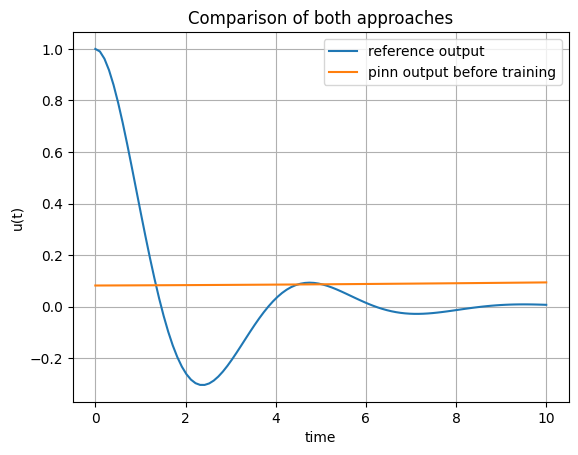

100

In [7]:
plt.plot(t_inter, u_ref, label="reference output")
plt.plot(t_inter, result, label="pinn output before training")
plt.title("Comparison of both approaches")
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()
len(t_inter)

## We now prepare the functions which retrieve the first and second order derivatives of U_theta

In [8]:
# key, sampling_key = jr.split(key)
# colocation_points = jr.uniform(sampling_key, interval_size, minval=0.0 + eps, maxval = t_max - eps)


def gradients(network, time):
    """
    coord: scalar t
    Returns: all necessary derivatives.
    """

    def get_U(c):
        return network(c)[0]

    dU_dt = jax.grad(get_U)(time)  # Value here, not (1,)
    dU2_dt2 = jax.hessian(get_U)(time)  # same remark

    return dU_dt, dU2_dt2


# gradients(pinn,t_inter[0])


def phys_residuals(network, time, m, c, k):

    U_theta = network(time)
    dU_dt, dU2_dt2 = gradients(network, time)

    res_U = m * dU2_dt2 + c * dU_dt + k * U_theta

    return res_U


def loss_fn_ic(network, inter, m, c, k, LAMBDA_phys, LAMBDA_IC, sampling_key):
    """
    Input: network (the NN), inter, inter, the considered time interval,
    """
    eps = 1e-5
    N_coloc = 5 * inter.shape[0]
    inter_min, inter_max = inter[0], inter[-1]
    random_interval = jr.uniform(
        sampling_key, shape=(N_coloc,), minval=inter_min + eps, maxval=inter_max
    )

    phys_residual = jax.vmap(phys_residuals, in_axes=(None, 0, None, None, None))(
        network, random_interval, m, c, k
    )

    phys_loss = jnp.mean(jnp.square(phys_residual))

    dU_dt0, _ = gradients(network, inter_min)

    IC_1 = network(inter_min) - 1.0
    IC_2 = dU_dt0 - 0.0

    IC_loss = jnp.mean(jnp.square(IC_1)) + jnp.mean(
        jnp.square(IC_2)
    )  # the jnp.means are not useful here, but we are assuming general case

    total_loss = LAMBDA_phys * phys_loss + LAMBDA_IC * IC_loss

    return total_loss


def data_loss_fn(network, inter, u_reference):

    predictions = jax.vmap(network)(inter)
    if len(inter) == len(u_reference):
        return jnp.mean(jnp.square(predictions - u_reference[:, None]))
    else:
        return 0


def loss_fn(
    network,
    inter,
    LAMBDA_phys,
    LAMBDA_data,
    sampling_key,
    m=M,
    c=C,
    k=K,
    u_reference=u_ref,
):
    """
    Input: network (the NN), inter, inter, the considered time interval,
    """
    N_coloc = inter.shape[0]

    inter_min, inter_max = inter[0], inter[-1]

    random_interval = jr.uniform(
        sampling_key, shape=(N_coloc,), minval=inter_min, maxval=inter_max
    )

    phys_residual = jax.vmap(phys_residuals, in_axes=(None, 0, None, None, None))(
        network, random_interval, m, c, k
    )

    phys_loss_contrib = LAMBDA_phys * jnp.mean(jnp.square(phys_residual))

    data_loss_contrib = LAMBDA_data * data_loss_fn(network, inter, u_reference)

    total_loss = phys_loss_contrib + data_loss_contrib

    return total_loss, (phys_loss_contrib, data_loss_contrib)


**How the loss is built:**

The total loss combines two terms:

$$\mathcal{L} = \lambda_\text{phys}\,\mathcal{L}_\text{phys} + \lambda_\text{data}\,\mathcal{L}_\text{data}$$

- **Physics loss** $\mathcal{L}_\text{phys}$: measures how much the network violates the ODE. At each training step a fresh set of **collocation points** is sampled uniformly in $[0, t_\text{max}]$, and the residual $m\ddot{u}_\theta + c\dot{u}_\theta + ku_\theta$ is squared and averaged. Random resampling acts as a form of stochastic regularization — the network cannot memorize a fixed grid.

- **Data loss** $\mathcal{L}_\text{data}$: standard MSE between the network output and the reference trajectory on the 100-point grid.

- **`loss_fn_ic`** (defined but not used in Part 1): an alternative formulation that enforces $u(0)=1$ and $\dot{u}(0)=0$ explicitly as penalty terms instead of relying on the data to impose them. Kept here for reference.

The weighting $\lambda_\text{phys} = 10,\ \lambda_\text{data} = 1$ is set in the training loop below; the physics term is upweighted because we have dense data already — the physics must not be overshadowed.

In [9]:
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))


@eqx.filter_jit
def make_step(network, state, inter, LAMBDA_phys, LAMBDA_data, sampling_key):

    loss_and_aux, grad = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
        network,
        inter,
        LAMBDA_phys,
        LAMBDA_data,
        sampling_key,
    )

    tot_loss, (phys_loss_contrib, data_loss_contrib) = loss_and_aux

    updates, new_state = optimizer.update(grad, state, network)
    new_network = eqx.apply_updates(network, updates)

    return new_network, new_state, tot_loss, phys_loss_contrib, data_loss_contrib


`eqx.filter_value_and_grad` computes the gradient of the loss with respect to all JAX arrays inside `network` (i.e. the weights), while ignoring non-array fields like `t_max`. `@eqx.filter_jit` JIT-compiles the whole step so it runs on the accelerator without Python overhead after the first call.

In [10]:
# Training loop

LAMBDA_PHYS = 10.0
LAMBDA_DATA = 1.0
EPOCHS = 1000

optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

loss_history = []
phys_loss_history = []
data_loss_history = []
key_for_loop = jr.PRNGKey(42)
for epoch in range(EPOCHS):
    key_for_loop, subkey_for_loop = jr.split(key_for_loop)
    pinn, opt_state, loss, phys_loss, data_loss = make_step(
        pinn,
        opt_state,
        t_inter,
        LAMBDA_PHYS,
        LAMBDA_DATA,
        subkey_for_loop,
    )
    loss_history.append(loss)
    phys_loss_history.append(phys_loss)
    data_loss_history.append(data_loss)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss}")

Epoch: 0, loss: 0.38170167803764343
Epoch: 10, loss: 0.09140526503324509
Epoch: 20, loss: 0.07877630740404129
Epoch: 30, loss: 0.07862737029790878
Epoch: 40, loss: 0.07832992076873779
Epoch: 50, loss: 0.07794584333896637
Epoch: 60, loss: 0.07823362201452255
Epoch: 70, loss: 0.07741707563400269
Epoch: 80, loss: 0.07763621211051941
Epoch: 90, loss: 0.0777319073677063
Epoch: 100, loss: 0.07748328149318695
Epoch: 110, loss: 0.07700186967849731
Epoch: 120, loss: 0.07659168541431427
Epoch: 130, loss: 0.07700848579406738
Epoch: 140, loss: 0.07655312865972519
Epoch: 150, loss: 0.07392112165689468
Epoch: 160, loss: 0.07274151593446732
Epoch: 170, loss: 0.07460017502307892
Epoch: 180, loss: 0.06735656410455704
Epoch: 190, loss: 0.05976961553096771
Epoch: 200, loss: 0.06278318911790848
Epoch: 210, loss: 0.04822121560573578
Epoch: 220, loss: 0.038284774869680405
Epoch: 230, loss: 0.0307761263102293
Epoch: 240, loss: 0.018386853858828545
Epoch: 250, loss: 0.026997463777661324
Epoch: 260, loss: 0.02

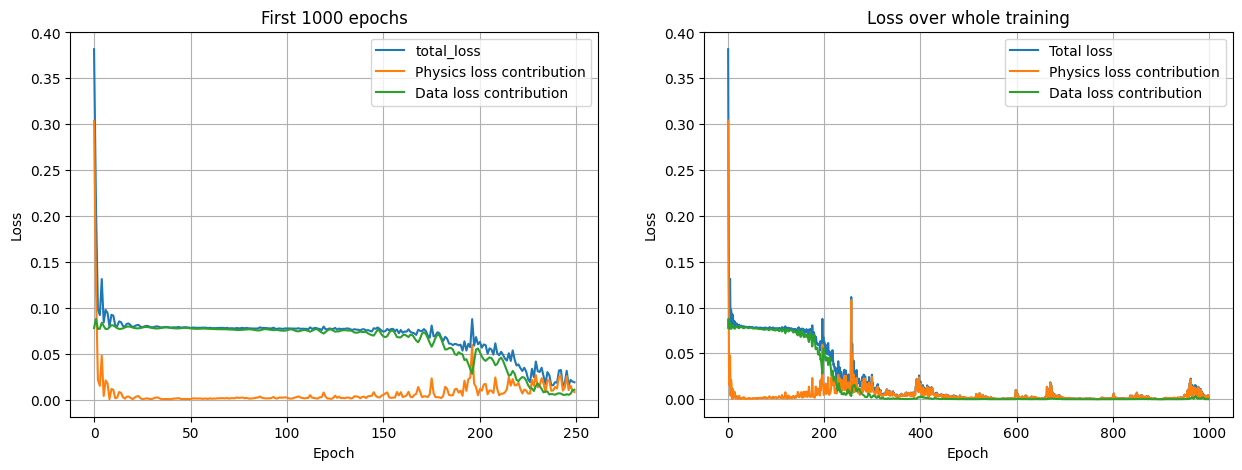

Best loss: 7.171941e-05


In [11]:
epochs = [i for i in range(EPOCHS)]
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs[0:250], loss_history[0:250], label="total_loss")
plt.plot(epochs[0:250], phys_loss_history[0:250], label="Physics loss contribution")
plt.plot(epochs[0:250], data_loss_history[0:250], label="Data loss contribution")
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("First 1000 epochs")


plt.subplot(1, 2, 2)

plt.plot(epochs, loss_history, label="Total loss")
plt.plot(epochs, phys_loss_history, label="Physics loss contribution")
plt.plot(epochs, data_loss_history, label="Data loss contribution")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over whole training")
plt.legend()
plt.grid()

plt.show()

print("Best loss:", min(loss_history))

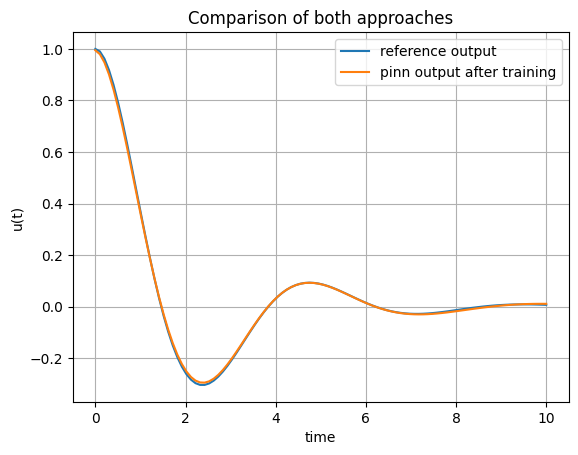

In [12]:
result_trained = jax.vmap(pinn)(t_inter)

plt.plot(t_inter, u_ref, label="reference output")
plt.plot(t_inter, result_trained, label="pinn output after training")
plt.title("Comparison of both approaches")
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()

With 100 dense data points and known parameters, the PINN converges quickly and the output closely matches the reference. This is the easiest scenario: the data loss guides the trajectory directly, and the physics loss keeps the solution physically consistent between data points.

---

## Part 2: We still consider $k,c,m$ known. We now have a lot less data points (say 10x less)

**Motivation for Part 2:** in practice, measurements are expensive or noisy and we may only have a handful of observations. Here we keep only 10 randomly chosen points from the 100-point reference, which is a 10× reduction. Without physics, a plain neural network would overfit those 10 points and produce a meaningless interpolation everywhere else. The physics loss is what prevents this — it enforces the ODE across the whole domain even where no data exists.

In [13]:
K = 2.0
M = 1.0
C = 1.0
t_max = 10.0
LEARNING_RATE = 1e-2


In [14]:
# Reference function
from scipy.integrate import solve_ivp


def reference_function(t_eval, m=M, c=C, k=K, u0=1.0, v0=0.0):
    """Compute the numerical solution using Scipy's Runge-Kutta solver"""

    # Define the system of 1st-order ODEs
    def dY_dt(t, Y):
        u, v = Y
        du_dt = v
        dv_dt = -(c * v + k * u) / m
        return [du_dt, dv_dt]

    # Time span needs to cover the evaluation points
    t_span = (float(t_eval[0]), float(t_eval[-1]))
    Y0 = [u0, v0]

    # solve_ivp returns an object; sol.y[0] contains the displacements
    sol = solve_ivp(dY_dt, t_span, Y0, t_eval=t_eval, method="RK45")

    return sol.y[0]

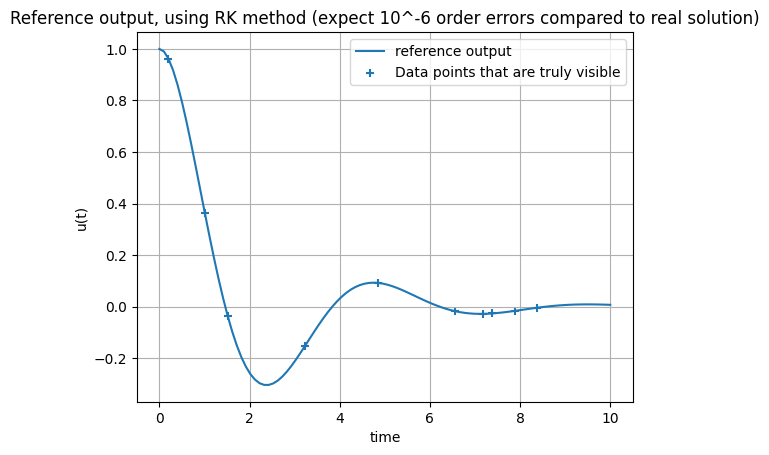

In [15]:
key = jr.PRNGKey(42)
key, subkey = jr.split(key)

t_inter = jnp.linspace(0, int(t_max), 100)

# Note: we are choosing random points within t_inter with uniform proba
# we could add a bias if we wanted to because instruments have a certain sensitivity for example
random_indices = jr.choice(subkey, jnp.arange(len(t_inter)), shape=(10,), replace=False)

u_ref = reference_function(t_inter)

t_data_sparse = t_inter[random_indices]
u_data_sparse = u_ref[random_indices]


plt.plot(t_inter, u_ref, label="reference output")
plt.scatter(
    t_data_sparse, u_data_sparse, marker="+", label="Data points that are truly visible"
)
plt.title(
    "Reference output, using RK method (expect 10^-6 order errors compared to real solution)"
)
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()

## Onto the PINN

We start with a simple architecture. 

In [16]:
key = jr.PRNGKey(42)
key, init_key = jr.split(key)


class NormalizedPINN(eqx.Module):
    mlp: eqx.nn.MLP

    # domain boundaries
    t_max: float = t_max

    def __init__(self, key):
        # Build the architecture and store it inside 'self.mlp'
        self.mlp = eqx.nn.MLP(
            # in_size=3,
            in_size=1,
            out_size=1,
            width_size=64,
            depth=4,
            activation=jax.nn.silu,
            key=key,
        )

    def __call__(self, coords):
        # Intercept the coordinates and normalize them then centers around 0 +/- 1
        t_norm = (coords / self.t_max) * 2.0 - 1.0
        scaled_coords = jnp.array([t_norm])

        # Pass the safe, normalized coordinates to the architecture
        return self.mlp(scaled_coords)


pinn_degraded_t = NormalizedPINN(init_key)

In [17]:
t0 = t_inter[0]
print("output of the pinn in [t=0],", pinn(t0)[0])


result_degraded = jax.vmap(pinn_degraded_t)(t_inter)
# print("output for each point:", result)


output of the pinn in [t=0], 0.9946083


## Now we can plot both curves to see what is going on

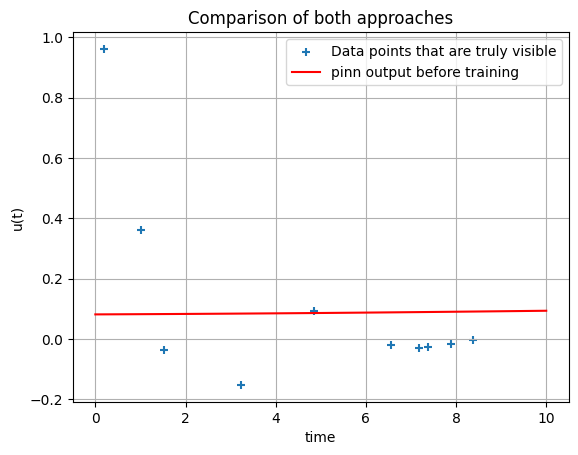

100

In [18]:
plt.scatter(
    t_data_sparse, u_data_sparse, marker="+", label="Data points that are truly visible"
)
plt.plot(t_inter, result, label="pinn output before training", color="red")
plt.title("Comparison of both approaches")
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()
len(t_inter)

## We now prepare the functions which retrieve the first and second order derivatives of U_theta

In [19]:
def gradients(network, time):
    """
    coord: scalar t
    Returns: all necessary derivatives.
    """

    def get_U(c):
        return network(c)[0]

    dU_dt = jax.grad(get_U)(time)  # Value here, not (1,)
    dU2_dt2 = jax.hessian(get_U)(time)  # same remark

    return dU_dt, dU2_dt2


# gradients(pinn,t_inter[0])


def phys_residuals(network, time, m, c, k):

    U_theta = network(time)
    dU_dt, dU2_dt2 = gradients(network, time)

    res_U = m * dU2_dt2 + c * dU_dt + k * U_theta

    return res_U


def data_loss_fn(network, inter, u_reference):

    predictions = jax.vmap(network)(inter)
    if len(inter) == len(u_reference):
        return jnp.mean(jnp.square(predictions - u_reference[:, None]))
    else:
        return 0


def loss_fn(
    network,
    inter,
    data_inter,
    LAMBDA_phys,
    LAMBDA_data,
    sampling_key,
    u_reference,
    m=M,
    c=C,
    k=K,
):
    """
    Input: network (the NN), inter, inter, the considered time interval,
    """
    N_coloc = 10 * inter.shape[0]

    inter_min, inter_max = inter[0], inter[-1]

    random_interval = jr.uniform(
        sampling_key, shape=(N_coloc,), minval=inter_min, maxval=inter_max
    )

    phys_residual = jax.vmap(phys_residuals, in_axes=(None, 0, None, None, None))(
        network, random_interval, m, c, k
    )

    phys_loss_contrib = LAMBDA_phys * jnp.mean(jnp.square(phys_residual))

    data_loss_contrib = LAMBDA_data * data_loss_fn(network, data_inter, u_reference)

    total_loss = phys_loss_contrib + data_loss_contrib

    return total_loss, (phys_loss_contrib, data_loss_contrib)


The loss function is identical in structure to Part 1, with two differences:

1. **Separate `data_inter` argument**: the data grid (`t_data_sparse`, 10 points) is now decoupled from the collocation grid (`t_inter`, 100 points). Physics is enforced everywhere; data is only imposed at the 10 observed locations.
2. **More collocation points**: `N_coloc = 10 × len(t_inter) = 1000` per step. With sparser data the physics constraint must work harder, so we sample more points to cover the domain well.

In [20]:
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))


@eqx.filter_jit
def make_step(
    network,
    state,
    inter,
    data_inter,
    LAMBDA_phys,
    LAMBDA_data,
    sampling_key,
    u_degraded,
):

    loss_and_aux, grad = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
        network,
        inter,
        data_inter,
        LAMBDA_phys,
        LAMBDA_data,
        sampling_key,
        u_degraded,
    )

    tot_loss, (phys_loss_contrib, data_loss_contrib) = loss_and_aux

    updates, new_state = optimizer.update(grad, state, network)
    new_network = eqx.apply_updates(network, updates)

    return new_network, new_state, tot_loss, phys_loss_contrib, data_loss_contrib


In [21]:
# Training loop

LAMBDA_PHYS = 10.0
LAMBDA_DATA = 1.0
EPOCHS = 1000

optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn_degraded_t, eqx.is_array))

loss_history = []
phys_loss_history = []
data_loss_history = []
key_for_loop = jr.PRNGKey(42)
for epoch in range(EPOCHS):
    key_for_loop, subkey_for_loop = jr.split(key_for_loop)
    pinn_degraded_t, opt_state, loss, phys_loss, data_loss = make_step(
        pinn_degraded_t,
        opt_state,
        t_inter,
        t_data_sparse,
        LAMBDA_PHYS,
        LAMBDA_DATA,
        subkey_for_loop,
        u_data_sparse,
    )
    loss_history.append(loss)
    phys_loss_history.append(phys_loss)
    data_loss_history.append(data_loss)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss}")

Epoch: 0, loss: 0.404514878988266
Epoch: 10, loss: 0.11776085197925568
Epoch: 20, loss: 0.10727445036172867
Epoch: 30, loss: 0.10728897154331207
Epoch: 40, loss: 0.10521363466978073
Epoch: 50, loss: 0.10531800240278244
Epoch: 60, loss: 0.10467547178268433
Epoch: 70, loss: 0.1042964905500412
Epoch: 80, loss: 0.10345765203237534
Epoch: 90, loss: 0.10286819934844971
Epoch: 100, loss: 0.10097313672304153
Epoch: 110, loss: 0.0983429029583931
Epoch: 120, loss: 0.0941210463643074
Epoch: 130, loss: 0.08353454619646072
Epoch: 140, loss: 0.07235180586576462
Epoch: 150, loss: 0.062409982085227966
Epoch: 160, loss: 0.06010548770427704
Epoch: 170, loss: 0.09529053419828415
Epoch: 180, loss: 0.07263986766338348
Epoch: 190, loss: 0.04552068933844566
Epoch: 200, loss: 0.02505718357861042
Epoch: 210, loss: 0.11446895450353622
Epoch: 220, loss: 0.06974847614765167
Epoch: 230, loss: 0.047609418630599976
Epoch: 240, loss: 0.026705332100391388
Epoch: 250, loss: 0.02336014434695244
Epoch: 260, loss: 0.02404

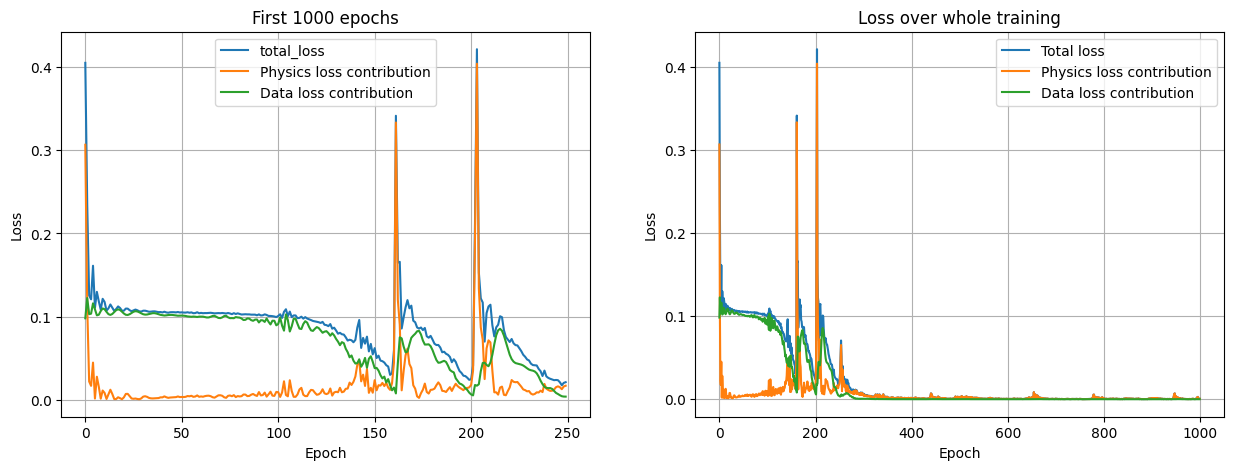

Best loss: 5.3677148e-05


In [22]:
epochs = [i for i in range(EPOCHS)]
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs[0:250], loss_history[0:250], label="total_loss")
plt.plot(epochs[0:250], phys_loss_history[0:250], label="Physics loss contribution")
plt.plot(epochs[0:250], data_loss_history[0:250], label="Data loss contribution")
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("First 1000 epochs")


plt.subplot(1, 2, 2)

plt.plot(epochs, loss_history, label="Total loss")
plt.plot(epochs, phys_loss_history, label="Physics loss contribution")
plt.plot(epochs, data_loss_history, label="Data loss contribution")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over whole training")
plt.legend()
plt.grid()

plt.show()

print("Best loss:", min(loss_history))

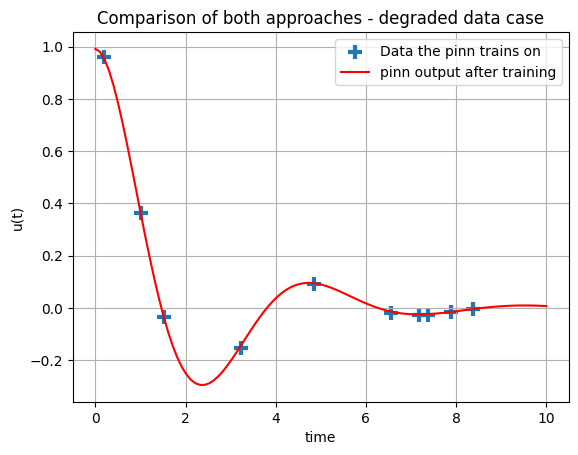

In [35]:
result_trained = jax.vmap(pinn_degraded_t)(t_inter)

# plt.plot(t_inter, u_ref, label="reference output")
plt.scatter(
    t_data_sparse,
    u_data_sparse,
    marker="+",
    label="Data the pinn trains on",
    s=100,
    linewidths=3,
)
plt.plot(t_inter, result_trained, label="pinn output after training", color="red")
plt.title("Comparison of both approaches - degraded data case")
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()

The PINN successfully reconstructs the full trajectory from only 10 data points. The physics loss acts as a strong regularizer, constraining the solution to follow the ODE between observations — something a standard data-only model could not achieve.

--- 
# Part 3: now the NN must guess the parameters $c, m, k$ with the degraded data

## Remark: 

We have to switch up the equation: 
$$\frac{d^2u}{dt^2}+\frac{c}{m}\frac{du}{dt} + \frac{k}{m}u = 0$$

Because we can't learn all 3 parameters at a time: the ratios will be respected but we can be off by a factor

**Why this matters — parameter identifiability:**

The original ODE $m\ddot{u} + c\dot{u} + ku = 0$ is not identifiable from trajectory data alone: any triple $(m, c, k)$ and $(2m, 2c, 2k)$ produce the same solution. The optimizer therefore cannot pin down absolute values — it will find a minimum for which only the ratios $c/m$ and $k/m$ are meaningful. We still learn all three as separate scalar parameters (to let the optimizer move freely), but the check at the end is on the ratios.

In [24]:
# Reference function
from scipy.integrate import solve_ivp


def reference_function(t_eval, m=M, c=C, k=K, u0=1.0, v0=0.0):
    """Compute the numerical solution using Scipy's Runge-Kutta solver"""

    # Define the system of 1st-order ODEs
    def dY_dt(t, Y):
        u, v = Y
        du_dt = v
        dv_dt = -(c * v + k * u) / m
        return [du_dt, dv_dt]

    # Time span needs to cover the evaluation points
    t_span = (float(t_eval[0]), float(t_eval[-1]))
    Y0 = [u0, v0]

    # solve_ivp returns an object; sol.y[0] contains the displacements
    sol = solve_ivp(dY_dt, t_span, Y0, t_eval=t_eval, method="RK45")

    return sol.y[0]

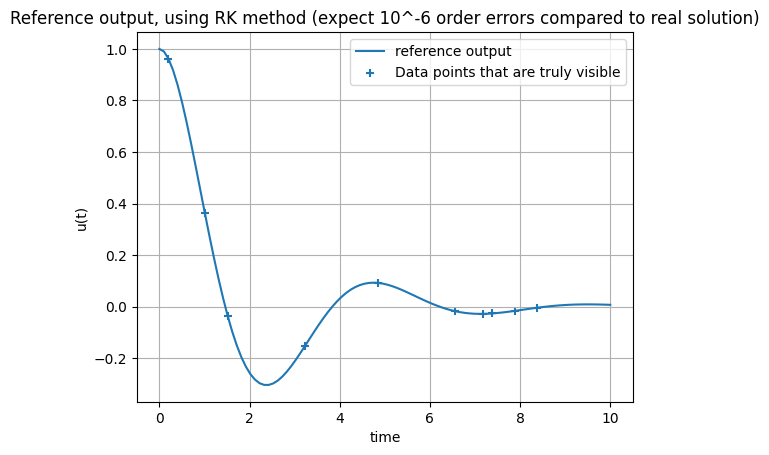

In [25]:
key = jr.PRNGKey(42)
key, subkey = jr.split(key)

t_inter = jnp.linspace(0, int(t_max), 100)

# Note: we are choosing random points within t_inter with uniform proba
# we could add a bias if we wanted to because instruments have a certain sensitivity for example
random_indices = jr.choice(subkey, jnp.arange(len(t_inter)), shape=(10,), replace=False)

u_ref = reference_function(t_inter)

t_data_sparse = t_inter[random_indices]
u_data_sparse = u_ref[random_indices]


plt.plot(t_inter, u_ref, label="reference output")
plt.scatter(
    t_data_sparse, u_data_sparse, marker="+", label="Data points that are truly visible"
)
plt.title(
    "Reference output, using RK method (expect 10^-6 order errors compared to real solution)"
)
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()

## Onto the PINN

We start with a simple architecture. 

In [26]:
key = jr.PRNGKey(42)
key, init_key = jr.split(key)


class InversePINN(eqx.Module):
    mlp: eqx.nn.MLP
    t_max: float

    # Define parameters as JAX arrays so Equinox/Optax knows to train them
    m_guess: jax.Array
    c_guess: jax.Array
    k_guess: jax.Array

    def __init__(self, key, t_max_val=t_max):
        self.mlp = eqx.nn.MLP(
            in_size=1,
            out_size=1,
            width_size=64,
            depth=4,
            activation=jax.nn.silu,
            key=key,
        )
        self.t_max = t_max_val

        # Initialize your unknown parameters (initial guesses)
        self.m_guess = jnp.array(1.0)
        self.c_guess = jnp.array(1.0)
        self.k_guess = jnp.array(1.0)

    def __call__(self, coords):
        t_norm = (coords / self.t_max) * 2.0 - 1.0
        scaled_coords = jnp.array([t_norm])
        return self.mlp(scaled_coords)


pinn_no_param = InversePINN(init_key)

The key difference from `NormalizedPINN`: the three physical parameters `m_guess`, `c_guess`, `k_guess` are stored as `jax.Array` fields. Because Equinox models are pytrees, these scalars are picked up by `eqx.filter(…, eqx.is_array)` exactly like the network weights, so Optax updates them alongside the MLP parameters with no extra code. The network architecture itself is unchanged.

In [27]:
t0 = t_inter[0]
# print("output of the pinn in [t=0],", pinn(t0)[0])


result_degraded = jax.vmap(pinn_no_param)(t_inter)
# print("output for each point:", result)


## Now we can plot both curves to see what is going on

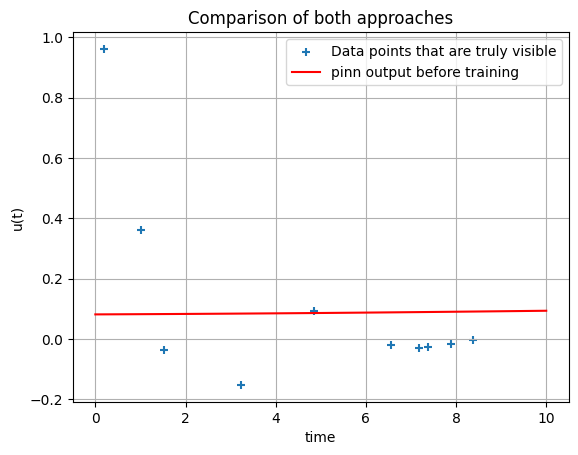

100

In [28]:
plt.scatter(
    t_data_sparse, u_data_sparse, marker="+", label="Data points that are truly visible"
)
plt.plot(t_inter, result, label="pinn output before training", color="red")
plt.title("Comparison of both approaches")
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()
len(t_inter)

## We now prepare the functions which retrieve the first and second order derivatives of U_theta

In [29]:
def gradients(network, time):
    """
    coord: scalar t
    Returns: all necessary derivatives.
    """

    def get_U(c):
        return network(c)[0]

    dU_dt = jax.grad(get_U)(time)  # Value here, not (1,)
    dU2_dt2 = jax.hessian(get_U)(time)  # same remark

    return dU_dt, dU2_dt2


# gradients(pinn,t_inter[0])


def phys_residuals(network, time):

    U_theta = network(time)
    dU_dt, dU2_dt2 = gradients(network, time)
    # force parameters to be positive, lol i found a negative mass once
    m = jnp.abs(network.m_guess)
    c = jnp.abs(network.c_guess)
    k = jnp.abs(network.k_guess)
    res_U = m * dU2_dt2 + c * dU_dt + k * U_theta

    return res_U


def data_loss_fn(network, inter, u_reference):

    predictions = jax.vmap(network)(inter)
    if len(inter) == len(u_reference):
        return jnp.mean(jnp.square(predictions - u_reference[:, None]))
    else:
        return 0


def loss_fn(
    network, inter, data_inter, LAMBDA_phys, LAMBDA_data, sampling_key, u_reference
):
    """
    Input: network (the NN), inter, inter, the considered time interval,
    """
    N_coloc = 10 * inter.shape[0]

    inter_min, inter_max = inter[0], inter[-1]

    random_interval = jr.uniform(
        sampling_key, shape=(N_coloc,), minval=inter_min, maxval=inter_max
    )

    phys_residual = jax.vmap(phys_residuals, in_axes=(None, 0))(
        network, random_interval
    )

    phys_loss_contrib = LAMBDA_phys * jnp.mean(jnp.square(phys_residual))

    data_loss_contrib = LAMBDA_data * data_loss_fn(network, data_inter, u_reference)

    total_loss = phys_loss_contrib + data_loss_contrib

    return total_loss, (phys_loss_contrib, data_loss_contrib)


Two changes compared to Part 2:

1. **`jnp.abs` on parameters**: without this constraint, gradient descent can push a parameter negative (e.g. negative mass). The absolute value keeps physical meaning while keeping the loss differentiable everywhere.
2. **Parameters read from `network` directly**: `phys_residuals` no longer accepts `m, c, k` as arguments — it reads `network.m_guess` etc. This is necessary because the gradients of the loss with respect to these scalars are computed through the same `filter_value_and_grad` call as the MLP weights.

In [30]:
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn_no_param, eqx.is_array))


@eqx.filter_jit
def make_step(
    network,
    state,
    inter,
    data_inter,
    LAMBDA_phys,
    LAMBDA_data,
    sampling_key,
    u_degraded,
):

    loss_and_aux, grad = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
        network,
        inter,
        data_inter,
        LAMBDA_phys,
        LAMBDA_data,
        sampling_key,
        u_degraded,
    )

    tot_loss, (phys_loss_contrib, data_loss_contrib) = loss_and_aux

    updates, new_state = optimizer.update(grad, state, network)
    new_network = eqx.apply_updates(network, updates)

    return new_network, new_state, tot_loss, phys_loss_contrib, data_loss_contrib


In [31]:
# Training loop

LAMBDA_PHYS = 10.0
LAMBDA_DATA = 1.0
EPOCHS = 10000

optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn_no_param, eqx.is_array))

loss_history = []
phys_loss_history = []
data_loss_history = []
key_for_loop = jr.PRNGKey(42)
for epoch in range(EPOCHS):
    key_for_loop, subkey_for_loop = jr.split(key_for_loop)
    pinn_no_param, opt_state, loss, phys_loss, data_loss = make_step(
        pinn_no_param,
        opt_state,
        t_inter,
        t_data_sparse,
        LAMBDA_PHYS,
        LAMBDA_DATA,
        subkey_for_loop,
        u_data_sparse,
    )
    loss_history.append(loss)
    phys_loss_history.append(phys_loss)
    data_loss_history.append(data_loss)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss}")

Epoch: 0, loss: 0.1759246289730072
Epoch: 10, loss: 0.10032474249601364
Epoch: 20, loss: 0.0739952027797699
Epoch: 30, loss: 0.017061280086636543
Epoch: 40, loss: 0.00760598573833704
Epoch: 50, loss: 0.005839495453983545
Epoch: 60, loss: 0.004226801451295614
Epoch: 70, loss: 0.004051055293530226
Epoch: 80, loss: 0.003667582757771015
Epoch: 90, loss: 0.0036219432950019836
Epoch: 100, loss: 0.0034925993531942368
Epoch: 110, loss: 0.0036589184310287237
Epoch: 120, loss: 0.003483062842860818
Epoch: 130, loss: 0.004342213273048401
Epoch: 140, loss: 0.0035160277038812637
Epoch: 150, loss: 0.0032651396468281746
Epoch: 160, loss: 0.0032802685163915157
Epoch: 170, loss: 0.0040167514234781265
Epoch: 180, loss: 0.00361506431363523
Epoch: 190, loss: 0.0032272436656057835
Epoch: 200, loss: 0.0031526202801615
Epoch: 210, loss: 0.0031731296330690384
Epoch: 220, loss: 0.0033257834147661924
Epoch: 230, loss: 0.0031018462032079697
Epoch: 240, loss: 0.0030972997192293406
Epoch: 250, loss: 0.0036594111006

Training is run for 10× more epochs than Parts 1–2 because the inverse problem is harder: the optimizer must jointly solve for the trajectory shape *and* the three physical scalars from only 10 data points. The loss landscape is more complex and the parameters need more gradient steps to settle.

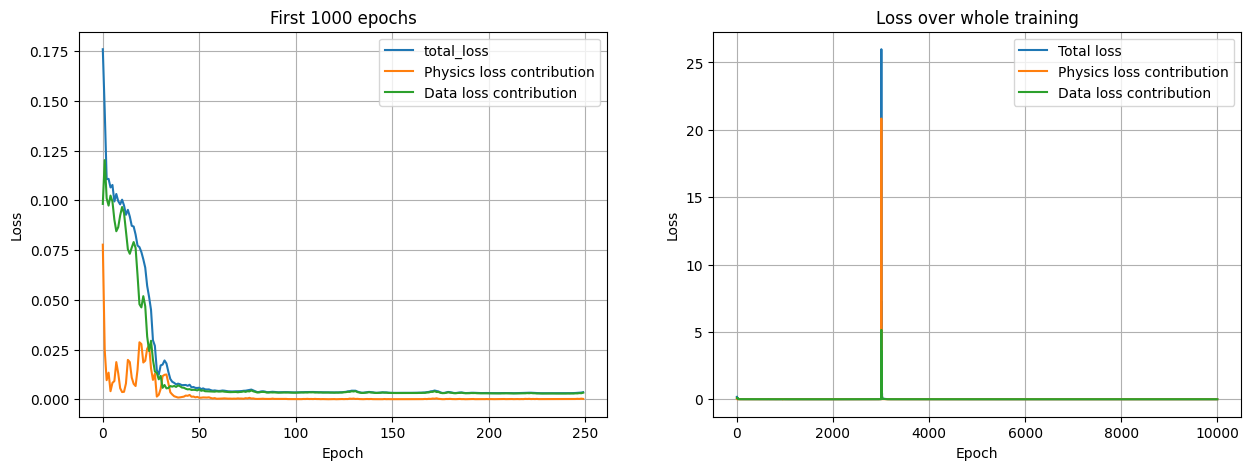

Best loss: 8.2649755e-08


In [32]:
epochs = [i for i in range(EPOCHS)]
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs[0:250], loss_history[0:250], label="total_loss")
plt.plot(epochs[0:250], phys_loss_history[0:250], label="Physics loss contribution")
plt.plot(epochs[0:250], data_loss_history[0:250], label="Data loss contribution")
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("First 1000 epochs")


plt.subplot(1, 2, 2)

plt.plot(epochs, loss_history, label="Total loss")
plt.plot(epochs, phys_loss_history, label="Physics loss contribution")
plt.plot(epochs, data_loss_history, label="Data loss contribution")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over whole training")
plt.legend()
plt.grid()

plt.show()

print("Best loss:", min(loss_history))

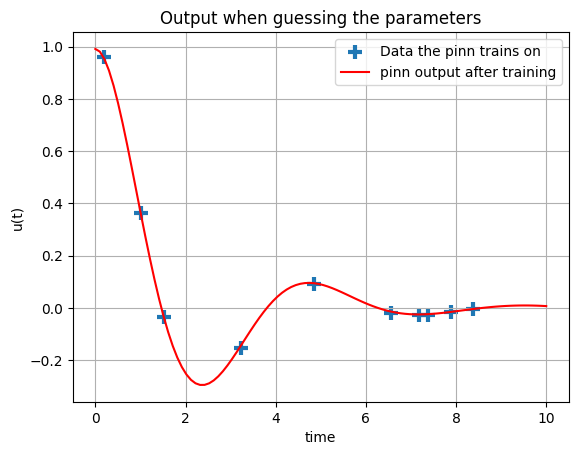

In [36]:
result_trained = jax.vmap(pinn_degraded_t)(t_inter)

# plt.plot(t_inter, u_ref, label="reference output")
plt.scatter(
    t_data_sparse,
    u_data_sparse,
    marker="+",
    label="Data the pinn trains on",
    s=100,
    linewidths=3,
)
plt.plot(t_inter, result_trained, label="pinn output after training", color="red")
plt.title("Output when guessing the parameters")
plt.grid()
plt.legend()
plt.xlabel("time")
plt.ylabel("u(t)")
plt.show()

In [34]:
# Extract the learned parameters from the trained network
learned_m = pinn_no_param.m_guess.item()
learned_c = pinn_no_param.c_guess.item()
learned_k = pinn_no_param.k_guess.item()

print("=== Learned Physical Parameters ===")
print(f"Mass (m):      {learned_m:.4f}")
print(f"Damping (c):   {learned_c:.4f}")
print(f"Stiffness (k): {learned_k:.4f}")

# It is also highly recommended to look at the ratios!
print("\n=== Parameter Ratios ===")
print(f"c/m (True: {C / M:.4f}): {learned_c / learned_m:.4f}")
print(f"k/m (True: {K / M:.4f}): {learned_k / learned_m:.4f}")

=== Learned Physical Parameters ===
Mass (m):      0.1185
Damping (c):   0.1186
Stiffness (k): 0.2368

=== Parameter Ratios ===
c/m (True: 1.0000): 1.0013
k/m (True: 2.0000): 1.9985


As expected from the identifiability argument, the absolute values of the learned parameters differ from the true $(m, c, k) = (1, 1, 2)$ — they are all scaled by roughly the same factor. However, the ratios $c/m$ and $k/m$ are recovered to high precision (within ~0.1 %), which is the physically meaningful result. In a real experiment where only the ODE structure is known, these ratios are exactly what one would report.